# Figure 4: Edge/Bump Population Geometry Dynamics

Goal:
- Use the same example trial as `fig4_edge_bump_single_trial_dynamics.ipynb`.
- Visualize simulated edge/bump population activity as 3D surfaces.
- x-axis: neural space; y-axis: time from stimulus onset; z-axis: firing rate.
- Diagnose whether the previously saved 80-neuron window was sufficient or truncated the population profile.


In [51]:
from __future__ import annotations

import json
import sys
from pathlib import Path
import matplotlib.colors as mcolors

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
%config InlineBackend.figure_format = 'retina'

REPO_ROOT = Path('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rate_model_core.config import NeuralGeometryConfig, build_geometry

DATA_ROOT = REPO_ROOT / 'results/figure4/fig4_edge_bump_full_profile_trial546'
FULL_PROFILE_PATH = DATA_ROOT / 'full_profile_trial546.npz'
SAVE_PATH = REPO_ROOT / 'figures/figure4/fig4_edge_bump_geometry_dynamics.png'
SAVE_PDF_PATH = SAVE_PATH.with_suffix('.pdf')

EXAMPLE_TRIAL_ID = 546
EXPECTED_TRIAL_SEED = 1940034869
EXPECTED_RT_MS = 550.0
EXPECTED_CHOICE = 1
EXPECTED_FINAL_X = 1.0
ORIGINAL_SELECTED_START = 472
ORIGINAL_SELECTED_STOP_EXCLUSIVE = 552
EXAMPLE_GLOBAL_INDICES = [482, 502, 522, 542]
EXAMPLE_TIMEPOINTS_MS = np.asarray([58.0, 211.0, 280.0, 464.0], dtype=float)
FIXED_NEURON_COLORS = ['#f2c14e', '#f28e2b', '#d95f02', '#8c2d04']

EDGE_COLOR = '#1d52a1'
BUMP_COLOR = '#716db2'

TIME_DOWNSAMPLE_TARGET = 140
NEURON_DOWNSAMPLE_TARGET = 256
VIEW_ELEV = 24
VIEW_AZIM = -58
SHOW_AXIS_LABELS = True

plt.rcParams.update({
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


In [52]:
if not FULL_PROFILE_PATH.exists():
    raise FileNotFoundError(
        (
            f"Missing full-profile dataset: {FULL_PROFILE_PATH}\n"
            "Generate it with:\n"
            "  bash figures_code/main/figure4/submit_fig4_full_profile_trial546_scc.sh\n"
            "or run scripts/generate_fig4_single_trial_dynamics_dataset.py with "
            "--trial-seeds 1940034869 and fig4_single_trial_full_profile_config.json."
        )
    )

with np.load(FULL_PROFILE_PATH, allow_pickle=False) as data:
    x_E = np.asarray(data['x_E'], dtype=np.float32)
    r_E = np.asarray(data['r_E'], dtype=np.float32)
    r_B = np.asarray(data['r_B'], dtype=np.float32)
    time_ms = np.asarray(data['time_ms'], dtype=float)
    choice = np.asarray(data['choice'])
    hit_boundary = np.asarray(data['hit_boundary']).astype(bool)
    rt_ms = np.asarray(data['rt_ms'], dtype=float)
    final_x = np.asarray(data['final_x'], dtype=float)
    metadata = json.loads(str(data['metadata_json'].item()))

# This dataset is generated as one trial, but keep the shape handling explicit.
if x_E.ndim == 2:
    x_E_trial = x_E[0]
else:
    x_E_trial = x_E
if r_E.ndim == 3:
    r_E_trial = r_E[0]
    r_B_trial = r_B[0]
else:
    r_E_trial = r_E
    r_B_trial = r_B

selected_global_indices = np.asarray(metadata['selected_neuron_indices'], dtype=int)
trial_seed = int(metadata['trial_seeds'][0])
trial_choice = int(choice[0])
trial_hit = bool(hit_boundary[0])
trial_rt_ms = float(rt_ms[0])
trial_final_x = float(final_x[0])
t_start_ms = float(metadata.get('t_start', 10))
boundary_time_ms = t_start_ms + trial_rt_ms if trial_hit and np.isfinite(trial_rt_ms) else float(time_ms[-1])

if trial_seed != EXPECTED_TRIAL_SEED:
    raise ValueError(f'Unexpected trial seed: {trial_seed} != {EXPECTED_TRIAL_SEED}')
if trial_choice != EXPECTED_CHOICE:
    raise ValueError(f'Unexpected choice: {trial_choice} != {EXPECTED_CHOICE}')
if abs(trial_rt_ms - EXPECTED_RT_MS) > 1.0:
    raise ValueError(f'Unexpected RT: {trial_rt_ms:.3f} ms != {EXPECTED_RT_MS:.3f} ms')
if abs(trial_final_x - EXPECTED_FINAL_X) > 1e-3:
    raise ValueError(f'Unexpected final_x: {trial_final_x:.6f} != {EXPECTED_FINAL_X:.6f}')

geometry_params = metadata.get('effective_geometry') or {
    'num_units': int(metadata.get('num_units', 1024)),
    'coding_limit': float(np.pi / 2),
    'coding_frac': 0.2,
    'clamp_frac': 0.1,
}
geometry = build_geometry(NeuralGeometryConfig(**geometry_params))
num_units = int(geometry_params['num_units'])
theta_all = geometry.theta_min + np.arange(num_units) / (num_units - 1) * (geometry.theta_max - geometry.theta_min)
selected_theta = theta_all[selected_global_indices]

pre_boundary_mask = time_ms <= min(float(time_ms[-1]), boundary_time_ms)
plot_time_ms = time_ms[pre_boundary_mask] - t_start_ms
r_E_pre = r_E_trial[pre_boundary_mask]
r_B_pre = r_B_trial[pre_boundary_mask]
x_E_pre = x_E_trial[pre_boundary_mask]
x_B_pre = x_B_trial[pre_boundary_mask]
print('dataset:', FULL_PROFILE_PATH)
print('trial_id:', EXAMPLE_TRIAL_ID)
print('trial_seed:', trial_seed)
print('choice:', trial_choice, 'hit:', trial_hit, 'rt_ms:', trial_rt_ms, 'final_x:', trial_final_x)
print('r_E full shape:', r_E_trial.shape)
print('r_B full shape:', r_B_trial.shape)
print('selected global index range:', int(selected_global_indices[0]), int(selected_global_indices[-1]))
print('theta bounds:', f'{selected_theta[0]:.2f}', f'{selected_theta[-1]:.2f}')
print('pre-boundary time range:', f'{plot_time_ms[0]:.1f}', f'{plot_time_ms[-1]:.1f}', 'ms')


dataset: /projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/results/figure4/fig4_edge_bump_full_profile_trial546/full_profile_trial546.npz
trial_id: 546
trial_seed: 1940034869
choice: 1 hit: True rt_ms: 550.0 final_x: 1.0
r_E full shape: (2000, 1024)
r_B full shape: (2000, 1024)
selected global index range: 0 1023
theta bounds: -7.85 7.85
pre-boundary time range: -10.0 550.0 ms


In [53]:
inside_old_window = (
    (selected_global_indices >= ORIGINAL_SELECTED_START)
    & (selected_global_indices < ORIGINAL_SELECTED_STOP_EXCLUSIVE)
)
outside_old_window = ~inside_old_window

if not np.any(outside_old_window):
    raise ValueError('This dataset does not include neurons outside the old 80-neuron window.')

edge_outside = r_E_pre[:, outside_old_window]
bump_outside = r_B_pre[:, outside_old_window]
edge_inside = r_E_pre[:, inside_old_window]
bump_inside = r_B_pre[:, inside_old_window]

# For edge neurons, values near either 0 or 1 are saturated plateaus.
edge_outside_unsaturated = np.minimum(np.abs(edge_outside), np.abs(edge_outside - 1.0))
edge_inside_unsaturated = np.minimum(np.abs(edge_inside), np.abs(edge_inside - 1.0))

bump_total_mass = np.sum(np.abs(r_B_pre), axis=1) + 1e-12
bump_outside_mass_fraction = np.sum(np.abs(bump_outside), axis=1) / bump_total_mass

print('Old saved window:', f'{ORIGINAL_SELECTED_START}:{ORIGINAL_SELECTED_STOP_EXCLUSIVE}')
print('Inside old window neuron count:', int(inside_old_window.sum()))
print('Outside old window neuron count:', int(outside_old_window.sum()))
print('Edge outside max unsaturated deviation from 0/1:', float(np.nanmax(edge_outside_unsaturated)))
print('Edge inside max unsaturated deviation from 0/1:', float(np.nanmax(edge_inside_unsaturated)))
print('Edge outside max temporal dynamic range per neuron:', float(np.nanmax(np.ptp(edge_outside, axis=0))))
print('Bump outside max firing rate:', float(np.nanmax(bump_outside)))
print('Bump inside max firing rate:', float(np.nanmax(bump_inside)))
print('Bump outside mass fraction: max=', float(np.nanmax(bump_outside_mass_fraction)), 'mean=', float(np.nanmean(bump_outside_mass_fraction)))


Old saved window: 472:552
Inside old window neuron count: 80
Outside old window neuron count: 944
Edge outside max unsaturated deviation from 0/1: 0.49999845027923584
Edge inside max unsaturated deviation from 0/1: 0.49997901916503906
Edge outside max temporal dynamic range per neuron: 0.840052604675293
Bump outside max firing rate: 1.0891306400299072
Bump inside max firing rate: 0.8593646287918091
Bump outside mass fraction: max= 0.9829826951026917 mean= 0.6973620057106018


/scratch/ipykernel_3620154/2526645481.py:270: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig(GEOMETRY_SAVE_PATH, dpi=300, bbox_inches='tight')


theta plot range: -3.92 3.63
display time range: 11.0 539.0 ms
example global indices: [482, 502, 522, 542]
example theta ticks: [-0.453, -0.146, 0.161, 0.468]
example time ticks: [58.0, 211.0, 280.0, 464.0]
dv example points: [(58.0, 0.411), (211.0, 0.411), (280.0, 0.71), (464.0, 0.709)]
dv hline ticks: [0.411, 0.71]
saved: /projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/figures/figure4/fig4_dv_trajectory_example_trial.png
saved: /projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/figures/figure4/fig4_dv_trajectory_example_trial.pdf
saved: /projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/figures/figure4/fig4_edge_bump_geometry_dynamics.png
saved: /projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/figures/figure4/fig4_edge_bump_geometry_dynamics.pdf


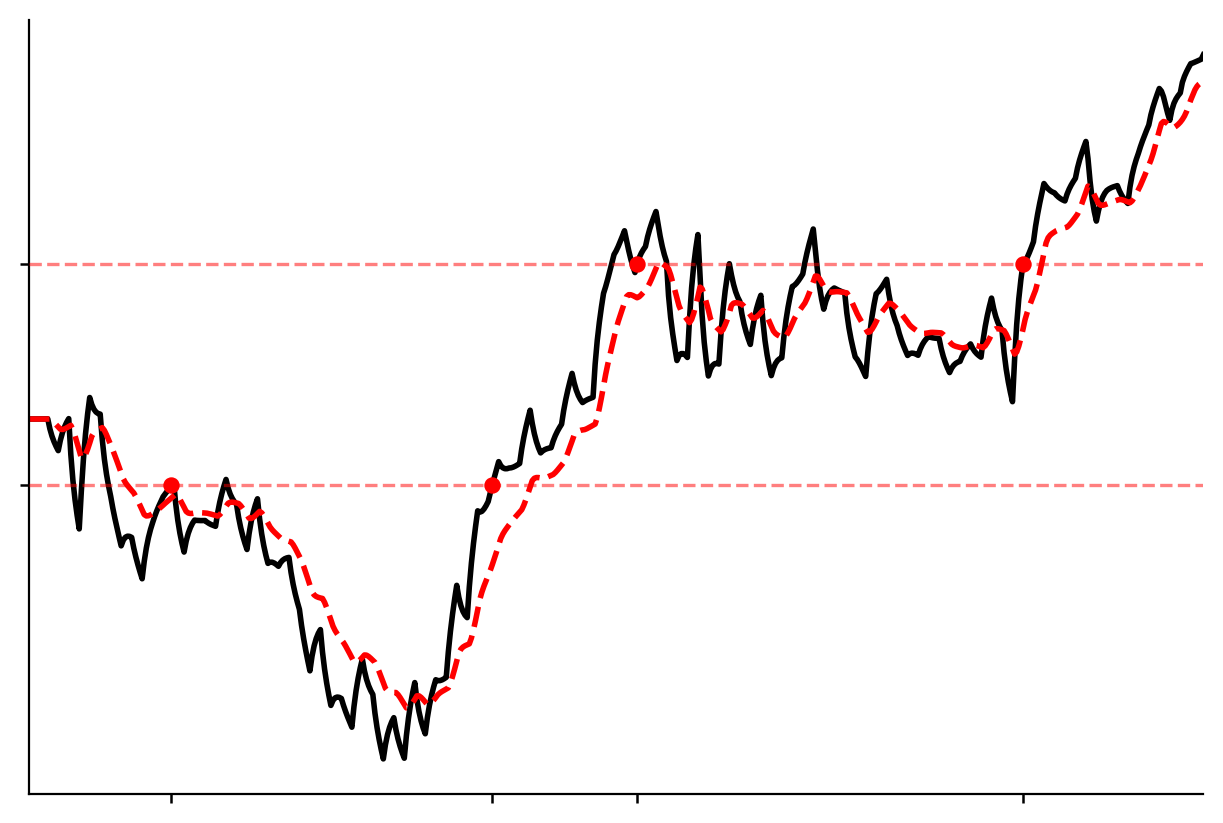

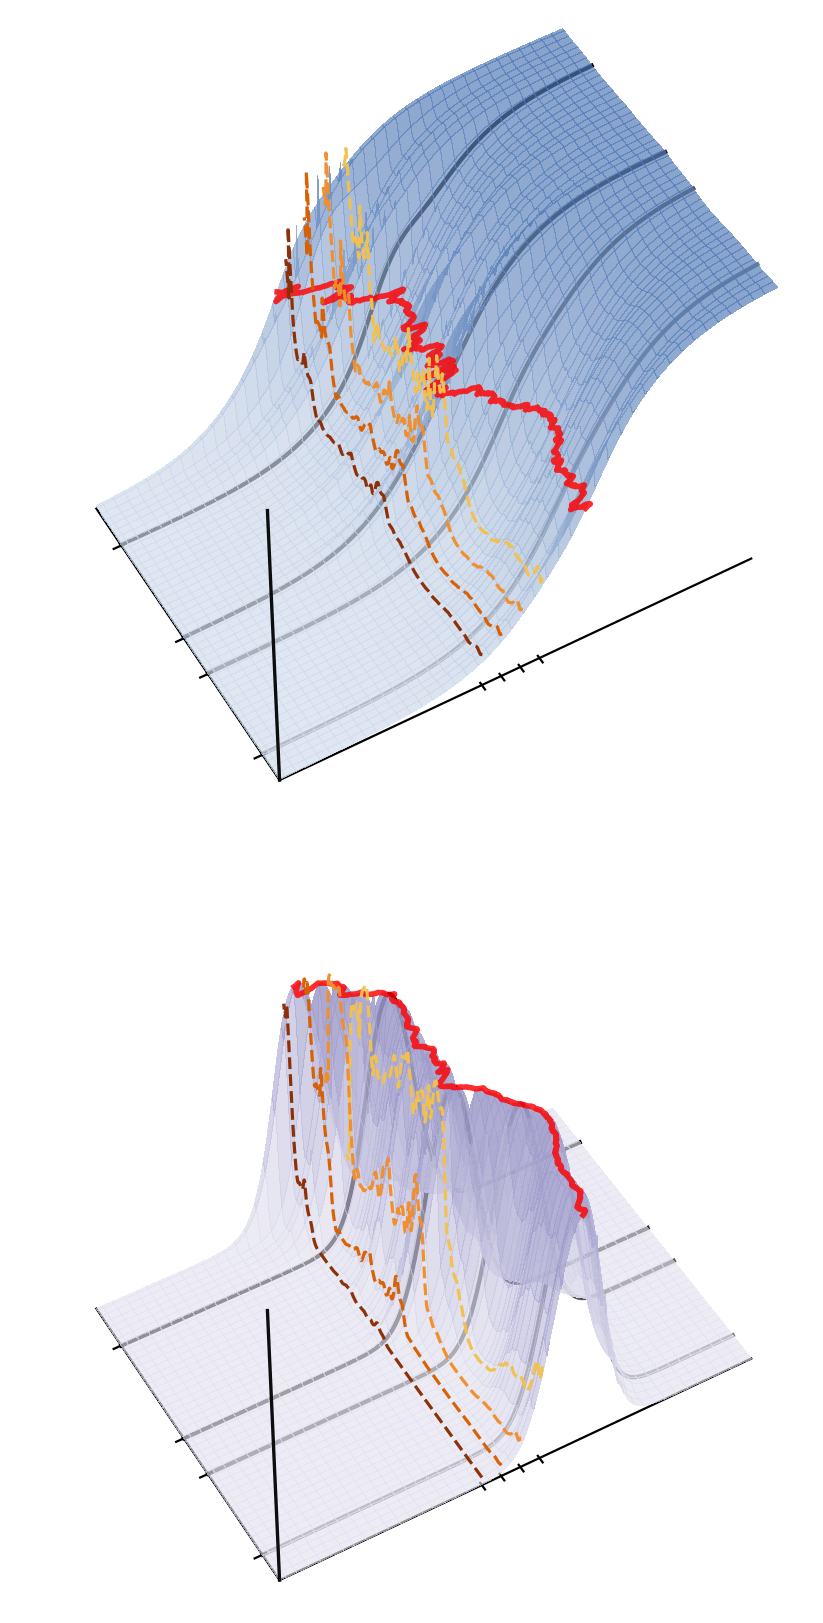

In [67]:
def blend_with_white(hex_color: str, amount: float) -> tuple[float, float, float, float]:
    rgb = np.asarray(mcolors.to_rgb(hex_color), dtype=float)
    blended = (1.0 - amount) * np.ones(3) + amount * rgb
    return (*blended, 1.0)


def downsample_indices(n: int, target: int) -> np.ndarray:
    if n <= target:
        return np.arange(n)
    return np.unique(np.linspace(0, n - 1, target).round().astype(int))


def active_theta_window(theta: np.ndarray, edge_rates: np.ndarray, bump_rates: np.ndarray, pad: float = 0.9):
    edge_dynamic = np.ptp(edge_rates, axis=0)
    bump_peak = np.nanmax(bump_rates, axis=0)
    mask = (edge_dynamic > 0.08) | (bump_peak > 0.05)
    if not np.any(mask):
        return theta
    lo = max(float(theta[0]), float(theta[mask][0]) - pad)
    hi = min(float(theta[-1]), float(theta[mask][-1]) + pad)
    return theta[(theta >= lo) & (theta <= hi)]


def theta_mask_from_window(theta: np.ndarray, theta_window: np.ndarray) -> np.ndarray:
    return (theta >= float(theta_window[0])) & (theta <= float(theta_window[-1]))


def surface_grid(theta: np.ndarray, time: np.ndarray, rates: np.ndarray):
    t_idx = downsample_indices(time.size, TIME_DOWNSAMPLE_TARGET)
    n_idx = downsample_indices(theta.size, NEURON_DOWNSAMPLE_TARGET)
    x_grid, y_grid = np.meshgrid(theta[n_idx], time[t_idx])
    z_grid = rates[np.ix_(t_idx, n_idx)]
    return x_grid, y_grid, z_grid


def rgba_surface_from_height(z_grid: np.ndarray, base_color: str, zmax: float, alpha: float = 0.56):
    base = np.asarray(mcolors.to_rgb(base_color), dtype=float)
    norm = np.clip(z_grid / max(float(zmax), 1e-9), 0.0, 1.0)
    # Keep the surface light; dark informative structure is carried by overlaid profiles/ridges.
    strength = 0.20 + 0.58 * norm
    rgb = (1.0 - strength[..., None]) * np.ones(3) + strength[..., None] * base
    return np.dstack([rgb, np.full_like(norm, alpha)])


def style_3d_axis(ax, zlim: tuple[float, float]):
    ax.view_init(elev=50, azim=-120)
    ax.grid(False)
    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)
    ax.set_zlim(*zlim)
    ax.set_box_aspect((1.75, 1.25, 1.35))
    # Remove all x/y/z ticks and ticklabels
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')
    ax.zaxis.line.set_color((1, 1, 1, 0))


def add_front_z_axis(ax, theta: np.ndarray, time: np.ndarray, zlim: tuple[float, float]):
    # Keep only the left-front z-axis line; no arrowhead.
    x0 = float(theta[-1])
    y0 = float(time[0])
    ax.plot([x0, x0], [y0, y0], [float(zlim[0]), float(zlim[1])], color='0.05', linewidth=1.2, zorder=20)


def plot_time_profiles(ax, theta: np.ndarray, time: np.ndarray, rates: np.ndarray, color: str):
    # Sparse profiles reveal how the full population shape evolves along the time axis.
    profile_times = EXAMPLE_TIMEPOINTS_MS
    alphas = np.linspace(0.5, 1.0, profile_times.size)
    for target_t, alpha in zip(profile_times, alphas):
        idx = int(np.argmin(np.abs(time - target_t)))
        ax.plot(
            theta,
            np.full_like(theta, time[idx]),
            rates[idx],
            color='black',
            alpha=float(alpha),
            linewidth=1.55,
            zorder=1,
        )


def plot_edge_front(ax, theta: np.ndarray, time: np.ndarray, rates: np.ndarray):
    # Edge front is the neural-space position closest to r=0.5 at each time.
    front_idx = np.argmin(np.abs(rates - 0.5), axis=1)
    ax.plot(
        theta[front_idx],
        time,
        rates[np.arange(time.size), front_idx],
        color="red",
        linewidth=2,
        alpha=0.82,
        zorder=8,
    )


def plot_bump_peak(ax, theta: np.ndarray, time: np.ndarray, rates: np.ndarray):
    peak_idx = np.argmax(rates, axis=1)
    ax.plot(
        theta[peak_idx],
        time,
        rates[np.arange(time.size), peak_idx],
        color="red",
        linewidth=2,
        alpha=0.82,
        zorder=8,
    )


def plot_fixed_neuron_time_courses(
    ax,
    theta: np.ndarray,
    time: np.ndarray,
    rates: np.ndarray,
    window_global_indices: np.ndarray,
):
    # Highlight each fixed neural coordinate as a narrow ribbon centered on the example neuron.
    # A true 1D fixed-theta line projects like a vertical bar in this view; the ribbon keeps it
    # attached to the surface while making the time-varying height visible.
    for global_idx, color in zip(EXAMPLE_GLOBAL_INDICES, FIXED_NEURON_COLORS):
        matches = np.flatnonzero(window_global_indices == int(global_idx))
        if matches.size != 1:
            raise ValueError(f'Example global neuron {global_idx} is outside the plotted theta window')
        local_idx = int(matches[0])
        lo = max(0, local_idx - 2)
        hi = min(theta.size, local_idx + 3)
        strip_theta = theta[lo:hi]
        strip_rates = rates[:, lo:hi] + 0.018
        strip_x, strip_y = np.meshgrid(strip_theta, time)
        color_rgba = np.array(plt.matplotlib.colors.to_rgba(color, alpha=0.82))
        facecolors = np.broadcast_to(color_rgba, strip_rates.shape + (4,)).copy()
        # ax.plot_surface(
        #     strip_x,
        #     strip_y,
        #     strip_rates,
        #     facecolors=facecolors,
        #     linewidth=0,
        #     antialiased=False,
        #     shade=False,
        #     zorder=12,
        # )
        # Draw the center trace on top of the ribbon for precise neural coordinate anchoring.
        ax.plot(
            np.full_like(time, theta[local_idx], dtype=float),
            time,
            rates[:, local_idx] + 0.028,
            color=color,
            linewidth=1.15,
            linestyle='--',
            alpha=0.98,
            zorder=13,
        )


theta_window = active_theta_window(selected_theta, r_E_pre, r_B_pre, pad=0.9)
window_mask = theta_mask_from_window(selected_theta, theta_window)
theta_plot = selected_theta[window_mask]
window_global_indices = selected_global_indices[window_mask]
r_E_plot_full_time = r_E_pre[:, window_mask]
r_B_plot_full_time = r_B_pre[:, window_mask]

display_time_mask = (plot_time_ms >= 0.02 * plot_time_ms[-1]) & (plot_time_ms <= 0.98 * plot_time_ms[-1])
plot_time_display = plot_time_ms[display_time_mask]
r_E_plot = r_E_plot_full_time[display_time_mask]
r_B_plot = r_B_plot_full_time[display_time_mask]

example_theta_ticks = []
for global_idx in EXAMPLE_GLOBAL_INDICES:
    matches = np.flatnonzero(window_global_indices == int(global_idx))
    if matches.size != 1:
        raise ValueError(f'Example global neuron {global_idx} is outside the plotted theta window')
    example_theta_ticks.append(float(theta_plot[int(matches[0])]))
example_theta_ticks = np.asarray(example_theta_ticks, dtype=float)

edge_zmax = max(1.0, float(np.nanmax(r_E_plot)))
bump_zmax = max(1.0, float(np.nanmax(r_B_plot)))

DV_SAVE_PATH = SAVE_PATH.with_name('fig4_dv_trajectory_example_trial.png')
DV_SAVE_PDF_PATH = DV_SAVE_PATH.with_suffix('.pdf')
GEOMETRY_SAVE_PATH = SAVE_PATH.with_name('fig4_edge_bump_geometry_dynamics.png')
GEOMETRY_SAVE_PDF_PATH = GEOMETRY_SAVE_PATH.with_suffix('.pdf')

x_E_display = x_E_pre[display_time_mask]
x_B_display = x_B_pre[display_time_mask]
example_time_indices = [int(np.argmin(np.abs(plot_time_display - target_t))) for target_t in EXAMPLE_TIMEPOINTS_MS]
example_dv_values = np.asarray([x_E_display[idx] for idx in example_time_indices], dtype=float)
low_dv = float(np.mean(example_dv_values[:2]))
high_dv = float(np.mean(example_dv_values[2:]))

# Figure 1: DV trajectory only.
fig_dv, ax_dv = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax_dv.plot(plot_time_ms, x_E_pre, color='black', linewidth=2)
ax_dv.plot(plot_time_ms, x_B_pre, color='red', linewidth=2, linestyle='--')

for idx in example_time_indices:
    ax_dv.scatter(plot_time_display[idx], x_E_display[idx], s=24, color='red', zorder=4)
for dv_level in (low_dv, high_dv):
    ax_dv.axhline(dv_level, color='red', linestyle='--', linewidth=1.2, alpha=0.5, zorder=3)
ax_dv.set_xlim(float(plot_time_ms[0]), float(plot_time_ms[-1]))
ax_dv.set_xticks(EXAMPLE_TIMEPOINTS_MS)
ax_dv.set_yticks([low_dv, high_dv])
ax_dv.set_xticklabels([])
ax_dv.set_yticklabels([])
ax_dv.set_xlabel('')
ax_dv.set_ylabel('')
for spine in ('top', 'right'):
    ax_dv.spines[spine].set_visible(False)
ax_dv.spines['left'].set_visible(True)
ax_dv.spines['bottom'].set_visible(True)
ax_dv.tick_params(axis='x', length=3.2, width=0.9, pad=1)
ax_dv.tick_params(axis='y', length=3.2, width=0.9, pad=1)

# Figure 2: Edge/Bump geometry only.
fig = plt.figure(figsize=(8, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=-0.05)
ax_edge = fig.add_subplot(gs[0, 0], projection='3d', proj_type='persp')
ax_bump = fig.add_subplot(gs[1, 0], projection='3d', proj_type='persp')

x_grid, y_grid, z_grid = surface_grid(theta_plot, plot_time_display, r_E_plot)
ax_edge.plot_surface(
    x_grid,
    y_grid,
    z_grid,
    facecolors=rgba_surface_from_height(z_grid, EDGE_COLOR, edge_zmax, alpha=0.68),
    linewidth=0,
    antialiased=False,
    shade=False,
)
plot_time_profiles(ax_edge, theta_plot, plot_time_display, r_E_plot, EDGE_COLOR)
plot_edge_front(ax_edge, theta_plot, plot_time_display, r_E_plot)
plot_fixed_neuron_time_courses(ax_edge, theta_plot, plot_time_display, r_E_plot, window_global_indices)
style_3d_axis(ax_edge, (0.0, edge_zmax))

x_grid, y_grid, z_grid = surface_grid(theta_plot, plot_time_display, r_B_plot)
ax_bump.plot_surface(
    x_grid,
    y_grid,
    z_grid,
    facecolors=rgba_surface_from_height(z_grid, BUMP_COLOR, bump_zmax, alpha=0.64),
    linewidth=0,
    antialiased=False,
    shade=False,
)
plot_time_profiles(ax_bump, theta_plot, plot_time_display, r_B_plot, BUMP_COLOR)
plot_bump_peak(ax_bump, theta_plot, plot_time_display, r_B_plot)
plot_fixed_neuron_time_courses(ax_bump, theta_plot, plot_time_display, r_B_plot, window_global_indices)
style_3d_axis(ax_bump, (0.0, bump_zmax))

for ax, zlim in ((ax_edge, (0.0, edge_zmax)), (ax_bump, (0.0, bump_zmax))):
    # Reverse neural-space direction in both panels so edge-front motion is easier to read.
    ax.set_xlim(float(theta_plot[-1]), float(theta_plot[0]))
    ax.set_ylim(float(plot_time_display[0]), float(plot_time_display[-1]))
    ax.set_xticks(example_theta_ticks)
    ax.set_yticks(EXAMPLE_TIMEPOINTS_MS)
    ax.set_zticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    add_front_z_axis(ax, theta_plot, plot_time_display, zlim)

SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig_dv.savefig(DV_SAVE_PATH, dpi=300, bbox_inches='tight')
fig.savefig(GEOMETRY_SAVE_PATH, dpi=300, bbox_inches='tight')
print('theta plot range:', f'{theta_plot[0]:.2f}', f'{theta_plot[-1]:.2f}')
print('display time range:', f'{plot_time_display[0]:.1f}', f'{plot_time_display[-1]:.1f}', 'ms')
print('example global indices:', EXAMPLE_GLOBAL_INDICES)
print('example theta ticks:', [round(float(v), 3) for v in example_theta_ticks])
print('example time ticks:', [round(float(v), 1) for v in EXAMPLE_TIMEPOINTS_MS])
print('dv example points:', [(round(float(plot_time_display[idx]), 1), round(float(x_E_display[idx]), 3)) for idx in example_time_indices])
print('dv hline ticks:', [round(low_dv, 3), round(high_dv, 3)])
print('saved:', DV_SAVE_PATH)
print('saved:', DV_SAVE_PDF_PATH)
print('saved:', GEOMETRY_SAVE_PATH)
print('saved:', GEOMETRY_SAVE_PDF_PATH)
